In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import sys
import os
# Adds parent diretory for imports
sys.path.append(os.path.abspath('..'))
# Add scripts folder for imports
sys.path.append('../scripts')

In [12]:
from dataloader import DataLoader
from data_cleaner import DataCleaner
from feature_engineering import FeatureEngineer
from config_paths import RAW_DATA_PATH

# 1. Load data
loader = DataLoader(RAW_DATA_PATH)
df = loader.load_data()
print("\n🔍 Raw Data:")
print(df.head())
# 2. Inspect
cleaner = DataCleaner(df)
cleaner.inspect_data()

# 3. Clean
df_clean = cleaner.clean_data()

print("\n Cleaned Data:")
print(df_clean.head())


✅ Data loaded successfully

🔍 Raw Data:
   customer_id  tenure  monthly_charges  total_charges        contract  \
0            1      52            54.20        2818.40  Month-to-month   
1            2      15            35.28         529.20  Month-to-month   
2            3      72            78.24        5633.28  Month-to-month   
3            4      61            80.24        4894.64        One year   
4            5      21            39.38         826.98  Month-to-month   

  payment_method internet_service tech_support online_security  support_calls  \
0         Credit              DSL           No             Yes              1   
1          Debit              DSL           No              No              2   
2          Debit              DSL           No              No              0   
3           Cash            Fiber          Yes             Yes              0   
4            UPI            Fiber           No              No              4   

  churn  
0    No  
1    No 

In [14]:
num_df = df_clean.select_dtypes(include = 'number')
print(num_df)

       customer_id  tenure  monthly_charges  total_charges  support_calls
0                1      52            54.20        2818.40              1
1                2      15            35.28         529.20              2
2                3      72            78.24        5633.28              0
3                4      61            80.24        4894.64              0
4                5      21            39.38         826.98              4
...            ...     ...              ...            ...            ...
19995        19996      36            69.51        2502.36              0
19996        19997      10            59.88         598.80              1
19997        19998       6            42.96         257.76              2
19998        19999       7           102.85         719.95              2
19999        20000      31            44.84        1390.04              1

[20000 rows x 5 columns]


In [16]:
cat_df = df_clean.select_dtypes(include = 'object')
print(cat_df)

             contract payment_method internet_service tech_support  \
0      Month-to-month         Credit              DSL           No   
1      Month-to-month          Debit              DSL           No   
2      Month-to-month          Debit              DSL           No   
3            One year           Cash            Fiber          Yes   
4      Month-to-month            UPI            Fiber           No   
...               ...            ...              ...          ...   
19995        Two year           Cash              DSL           No   
19996  Month-to-month            UPI            Fiber          Yes   
19997  Month-to-month         Credit            Fiber           No   
19998  Month-to-month          Debit              DSL          Yes   
19999        Two year         Credit            Fiber          Yes   

      online_security churn  
0                 Yes    No  
1                  No    No  
2                  No    No  
3                 Yes    No  
4        

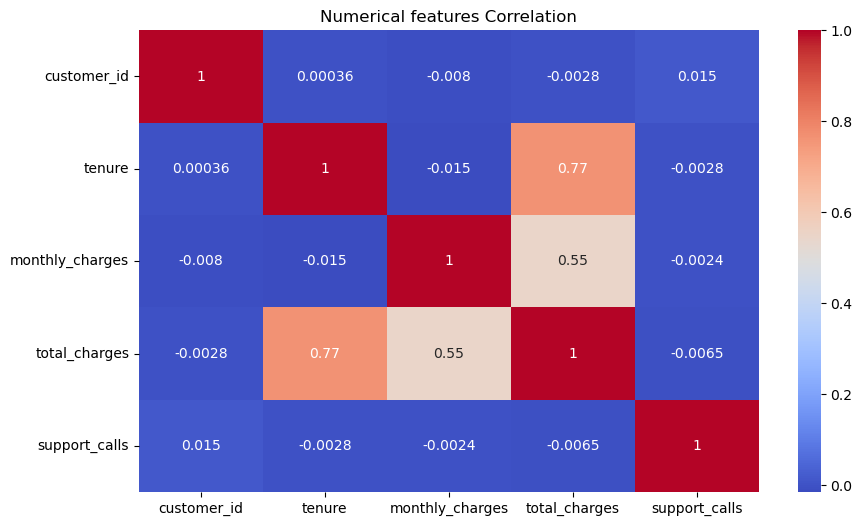

In [18]:
# Correlation heatmap for numerical columns to see their relation
plt.figure(figsize = (10,6))
corr = num_df.corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Numerical features Correlation")
plt.show()

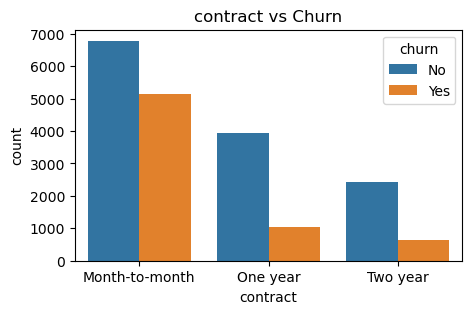

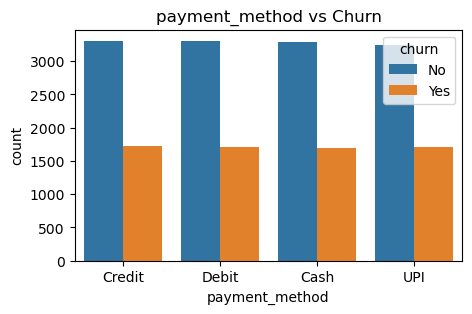

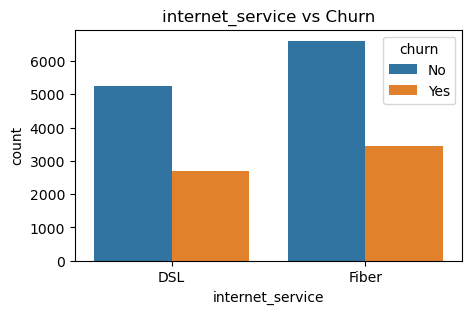

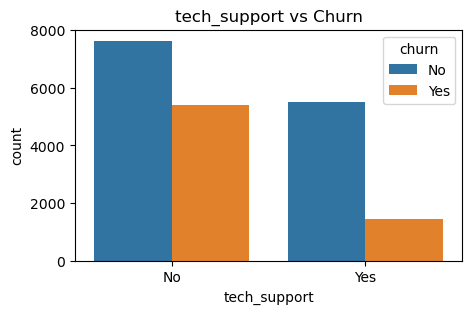

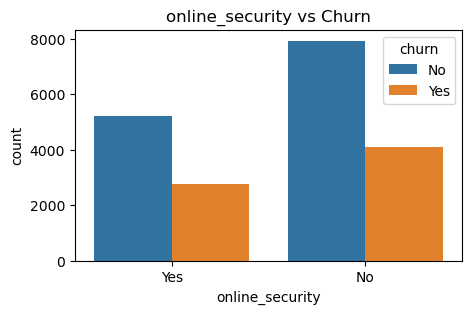

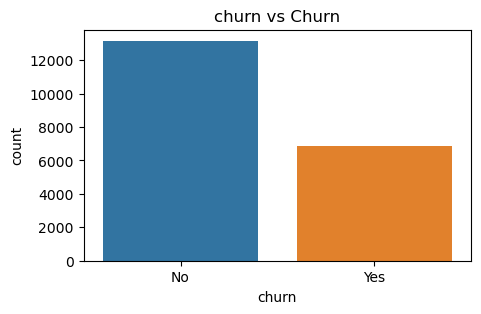

In [20]:
# Categorical features vs churn distribution
for col in cat_df:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

In [22]:
df_clean.columns

Index(['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls', 'churn'],
      dtype='object')

In [28]:
# Based on above analysis ( correlation analysis)
'''
From our correlation matrix analysis, we observed:

customer_id is a unique identifier with no predictive power → drop it.

tenure and total_charges have a high correlation (0.77) → we drop total_charges and keep tenure to avoid multicollinearity.

Dropped: customer_id, total_charges
'''
df_clean = df_clean.drop(columns = ['customer_id', 'total_charges'])
df_clean.head()

,tenure,monthly_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,52,54.20,Month-to-month,Credit,DSL,No,Yes,1,No
1,15,35.28,Month-to-month,Debit,DSL,No,No,2,No
2,72,78.24,Month-to-month,Debit,DSL,No,No,0,No
3,61,80.24,One year,Cash,Fiber,Yes,Yes,0,No
4,21,39.38,Month-to-month,UPI,Fiber,No,No,4,Yes


In [10]:
# Separate dependent and independent data for modeling
X = df_model.iloc[:,:-1]
y = df_model.iloc[:,-1]
print(X)

       tenure  monthly_charges        contract payment_method  \
0          52            54.20  Month-to-month         Credit   
1          15            35.28  Month-to-month          Debit   
2          72            78.24  Month-to-month          Debit   
3          61            80.24        One year           Cash   
4          21            39.38  Month-to-month            UPI   
...       ...              ...             ...            ...   
19995      36            69.51        Two year           Cash   
19996      10            59.88  Month-to-month            UPI   
19997       6            42.96  Month-to-month         Credit   
19998       7           102.85  Month-to-month          Debit   
19999      31            44.84        Two year         Credit   

      internet_service tech_support online_security  support_calls  
0                  DSL           No             Yes              1  
1                  DSL           No              No              2  
2           

In [11]:
numerical_data = X.select_dtypes(include ='number')
cat_data = X.select_dtypes(include = 'object')

In [12]:
print(y)

0         No
1         No
2         No
3         No
4        Yes
        ... 
19995    Yes
19996     No
19997     No
19998     No
19999    Yes
Name: churn, Length: 20000, dtype: object


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16000, 8)
X_test shape: (4000, 8)
y_train shape: (16000,)
y_test shape: (4000,)


In [14]:
# Define preprocessor to scale numerical data and one-hot encode categorical data

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_data.columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_data.columns)
    ]
)

In [15]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [16]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [17]:
y_train

array([0, 0, 0, ..., 1, 0, 0], shape=(16000,))

In [18]:
y_test

array([0, 1, 0, ..., 1, 0, 0], shape=(4000,))

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [53]:
class ChurnModel:
    
    def __init__(self, df):
        self.df = df
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.preprocessor = None
        self.models = {}
        self.pipelines = {}
        self.results = {}
        self.label_encoder = LabelEncoder()

    
    def prepare_data(self):
        self.X = self.df.drop('churn', axis=1)
        self.y = self.df['churn']

        self.num_cols = self.X.select_dtypes(include='number').columns
        self.cat_cols = self.X.select_dtypes(include='object').columns

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=0
        )

        self.y_train = self.label_encoder.fit_transform(self.y_train)
        self.y_test = self.label_encoder.transform(self.y_test)

        print("Data prepared")

    def build_preprocessor(self):
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), self.num_cols),
                ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), self.cat_cols)
            ]
        )
        print("Preprocessor ready")

    def load_models(self):
        self.models = {
            'Logistic Regression': LogisticRegression(random_state=0),
            'KNN': KNeighborsClassifier(),
            'SVM Linear': SVC(kernel='linear', random_state=0),
            'SVM RBF': SVC(kernel='rbf', random_state=0),
            'Naive Bayes': GaussianNB(),
            'Decision Tree': DecisionTreeClassifier(random_state=0),
            'Random Forest': RandomForestClassifier(random_state=0),
            'XGBoost': xgb.XGBClassifier(random_state=0)
        }
        print("Models loaded")

    def train_models(self):
        for name, model in self.models.items():
            pipeline = Pipeline([
                ('preprocessor', self.preprocessor),
                ('classifier', model)
            ])

            pipeline.fit(self.X_train, self.y_train)
            self.pipelines[name] = pipeline

            y_train_pred = pipeline.predict(self.X_train)
            y_test_pred = pipeline.predict(self.X_test)

            train_acc = accuracy_score(self.y_train, y_train_pred)
            test_acc = accuracy_score(self.y_test, y_test_pred)

            self.results[name] = {
                'Train Accuracy': train_acc,
                'Test Accuracy': test_acc
            }

            print(f"{name}: Train={train_acc:.4f}, Test={test_acc:.4f}")

    def evaluate_xgboost(self):
        xgb_pipeline = self.pipelines['XGBoost']

        y_pred = xgb_pipeline.predict(self.X_test)

        print("\nXGBoost Report:")
        print(classification_report(self.y_test, y_pred))

        ConfusionMatrixDisplay.from_estimator(xgb_pipeline, self.X_test, self.y_test)
        plt.show()

        cv_scores = cross_val_score(xgb_pipeline, self.X_train, self.y_train, cv=5)

        print(f"CV Mean: {cv_scores.mean():.4f}")
        print(f"CV Std: {cv_scores.std():.4f}")

    def predict_risk(self, customer_dict):
        df = pd.DataFrame([customer_dict])

        model = self.pipelines['XGBoost']

        pred = model.predict(df)[0]
        prob = model.predict_proba(df)[0][1]

        result = "High Risk" if pred == 1 else "Not High Risk"

        return f"{result} (Probability: {prob:.2%})"